# loadcast — a tutorial

Hourly heat, cold and electricity demand for an industrial site, from the few
numbers someone actually knows about a plant.

This notebook does two jobs at once. It is a **tutorial** — every feature, in
the order you would meet them — and it is the **derivation**: each piece of
mathematics sits next to the figure that demonstrates it, so you can see the
algebra do what it claims.

| section | question |
|---|---|
| 1 | What does it produce? |
| 2 | Why is the generator a product? |
| 3 | The residual, and its two constants |
| 4 | Reading the parameters off a measurement |
| 5 | Why spread multiplies instead of adding |
| 6 | Intermittency, and the capacity ceiling |
| 7 | **The coincidence problem** — the reason this package exists |
| 8 | The lag, and why it cannot be fitted |
| 9 | What a store actually responds to |
| 10 | Resolution |
| 11 | Waste heat |
| 12 | Fitting your own site |
| 13 | Only the carriers you have |
| 14 | Indicative published values |
| 15 | Limits, stated |

In [1]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import loadcast as lc
from loadcast import fitting, generator

FIG = Path("figures")
FIG.mkdir(exist_ok=True)

# One palette for the whole notebook. The three carriers are drawn in colours
# that stay distinguishable to a colourblind reader; waste heat is also dashed,
# so it never relies on hue alone.
C = {"heat": "#eb6834", "cold": "#2a78d6", "elec": "#1baf7a", "waste": "#4a3aa7"}
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 3.2),
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "font.size": 9, "axes.titlesize": 10, "axes.titleweight": "bold",
    "legend.frameon": False,
})

def save(name):
    plt.tight_layout()
    plt.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight")

print("loadcast", lc.__version__)
print("process classes:", lc.available_classes())

loadcast 0.1.0
process classes: ['batch', 'campaign', 'continuous', 'semi_continuous']


---
## 1. What does it produce?

Four inputs, an hourly year out.

In [2]:
profiles = lc.generate(
    annual_mwh=10_000,      # total energy the site uses in a year
    heat_to_cold=7.4,       # it wants 7.4x more heat than cold
    elec_share=0.20,        # a fifth of its energy is electricity
    process_class="semi_continuous",   # weekday shifts, weekend trough
)
profiles.head()

,heat_kw,cold_kw,elec_kw,waste_kw
2025-01-01 00:00:00,865.274883,208.628314,432.509259,0.0
2025-01-01 01:00:00,651.086463,181.178819,517.277158,0.0
2025-01-01 02:00:00,837.227139,193.344427,543.773078,0.0
2025-01-01 03:00:00,980.995530,152.058203,329.940953,0.0
2025-01-01 04:00:00,877.654752,127.695092,340.461056,0.0


In [3]:
lc.summary_table(profiles)

,mean_kw,peak_kw,load_factor,cv,lag1,idle_fraction,annual_mwh
heat_kw,804.5227,2006.2911,0.401,0.4649,0.8648,0.0,7047.619
cold_kw,108.7193,271.1204,0.401,0.4565,0.8626,0.0,952.381
elec_kw,228.3105,569.3529,0.401,0.4679,0.8679,0.0,2000.000
waste_kw,0.0000,0.0000,0.000,0.0000,0.0000,0.0,0.000


Four of those numbers are **exact by construction**, not fitted: the annual
energy, the heat:cold ratio, the electricity share and the load factor. Check
rather than trust:

In [4]:
energy = profiles.sum() / 1000          # kWh -> MWh
print(f"annual total     {energy.sum():10,.1f} MWh   (asked for 10,000)")
print(f"heat : cold      {energy['heat_kw'] / energy['cold_kw']:10.4f}       (asked for 7.4)")
print(f"electricity share{energy['elec_kw'] / energy.sum():10.4f}       (asked for 0.20)")
print(f"minimum value    {profiles.to_numpy().min():10.4f} kW    (never negative)")

annual total       10,000.0 MWh   (asked for 10,000)
heat : cold          7.4000       (asked for 7.4)
electricity share    0.2000       (asked for 0.20)
minimum value        0.0000 kW    (never negative)


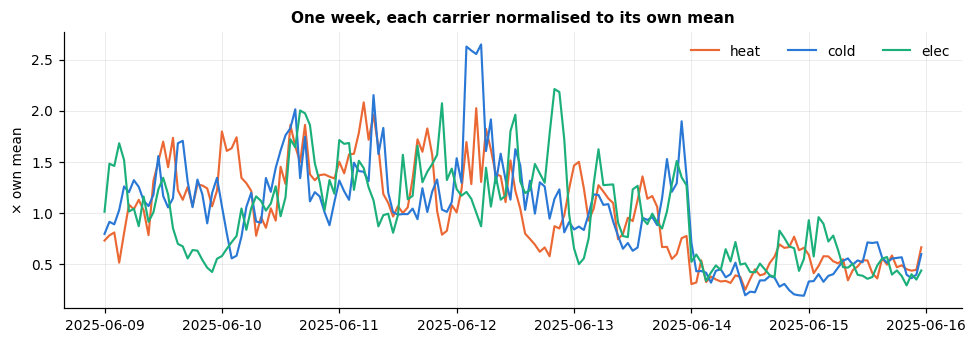

In [5]:
week = profiles.loc["2025-06-09":"2025-06-15"]
fig, ax = plt.subplots()
for key, col in (("heat", "heat_kw"), ("cold", "cold_kw"), ("elec", "elec_kw")):
    ax.plot(week.index, week[col] / week[col].mean(), color=C[key], lw=1.4, label=key)
ax.set_ylabel("× own mean")
ax.set_title("One week, each carrier normalised to its own mean")
ax.legend(ncol=3)
save("01_one_week")
plt.show()

---
## 2. Why the generator is a product

$$
P_m(t) \;=\; L_m \cdot S(t) \cdot M_m(t-\tau_m) \cdot R_m(t-\tau_m)
$$

where $P_m(t)$ is the demand for carrier $m$ at hour $t$ in kW, $L_m$ the level,
$S(t)$ the calendar factor, $M_m$ the on/off state, $R_m$ the residual
fluctuation and $\tau_m$ the carrier's lag in hours.

The factors **multiply** rather than add, and that is not a stylistic choice. A
multiplicative factor is dimensionless, so the same rhythm transfers between a
200 kW site and a 20 MW one with no retuning. Additive noise does not: "plus or
minus 50 kW" means something different at each scale, and it can push the load
below zero — which published generators do in up to a third of their steps.

Every factor on the right has mean one, so $L_m$ alone carries the level. That
is what makes the annual energy exact: nothing downstream of $L_m$ can move it.

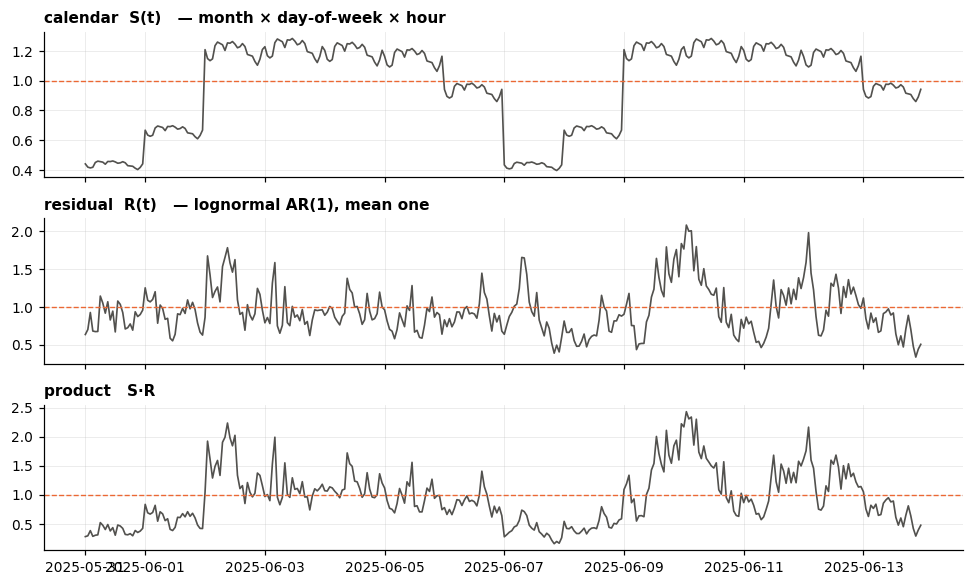

E[S] = 1.0003     E[R] = 0.9920     (both should be 1)


In [6]:
# Build the factors by hand, to see them separately.
index = pd.date_range("2025-01-01", periods=8760, freq="h")
process = lc.get_class("semi_continuous")
rng = np.random.default_rng(1)

calendar = process.calendar(index)
cv_residual = generator.residual_cv_for(process.target_cv, calendar)
sigma = fitting.sigma_from_cv(cv_residual)
latent = generator.correlated_ar1(8760, 1, phi=process.target_lag1,
                                  sigma=sigma, correlation=0.0, rng=rng)
residual = generator.lognormal_from_latent(latent, sigma)[0]
product = calendar * residual

fig, axes = plt.subplots(3, 1, figsize=(9, 5.4), sharex=True)
span = slice(3600, 3600 + 336)     # a fortnight
for ax, series, title in (
    (axes[0], calendar, "calendar  S(t)   — month × day-of-week × hour"),
    (axes[1], residual, "residual  R(t)   — lognormal AR(1), mean one"),
    (axes[2], product, "product   S·R"),
):
    ax.plot(index[span], series[span], color="#52514e", lw=1.1)
    ax.axhline(1.0, color=C["heat"], lw=0.9, ls="--")
    ax.set_title(title, loc="left")
axes[2].set_xlabel("")
save("02_decomposition")
plt.show()

print(f"E[S] = {calendar.mean():.4f}     E[R] = {residual.mean():.4f}     (both should be 1)")

---
## 3. The residual, and its two constants

$$
z(t) = \phi\,z(t-1) + \varepsilon(t), \qquad
\varepsilon \sim \mathcal{N}\!\big(0,\ \sigma^2(1-\phi^2)\big)
$$

$$
R(t) = \exp\!\Big(z(t) - \tfrac{1}{2}\sigma^2\Big)
$$

with $\phi \in [0,1)$ setting how long an excursion lasts and $\sigma$ how wide
it is. Two constants look arbitrary and are not.

**The factor $\sqrt{1-\phi^2}$.** An AR(1) driven by innovations of variance
$s^2$ settles at stationary variance $s^2/(1-\phi^2)$. Choosing
$s^2 = \sigma^2(1-\phi^2)$ makes the stationary variance exactly $\sigma^2$ —
and starting $z(0)$ from that distribution removes the burn-in entirely.
Without it the series *begins at zero variance and grows into its spread*.

**The term $-\sigma^2/2$.** For $z\sim\mathcal{N}(0,\sigma^2)$ we have
$\mathbb{E}[e^z] = e^{\sigma^2/2}$, which exceeds one and grows with the spread.
Subtracting $\sigma^2/2$ gives $\mathbb{E}[R]=1$ exactly, so widening the noise
cannot inflate the annual energy.

Both are easier to believe when you see them fail.

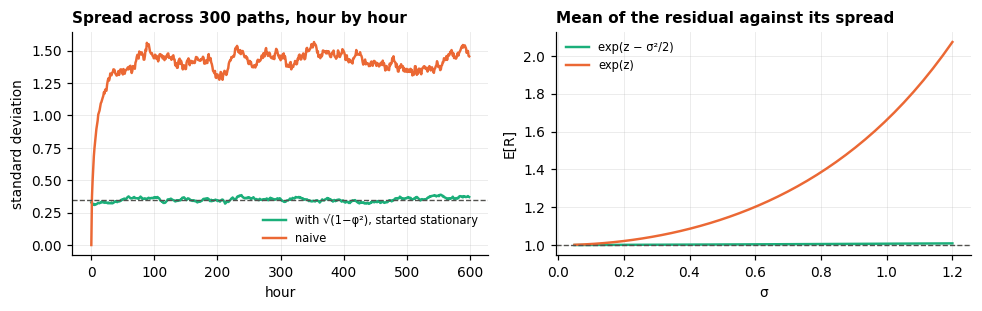

In [7]:
# An AR(1) built the obvious way: no stationarity factor, starting at zero.
def naive_ar1(n, phi, sigma, rng):
    z = np.zeros(n)
    for t in range(1, n):
        z[t] = phi * z[t - 1] + rng.standard_normal() * sigma
    return z

rng = np.random.default_rng(0)
phi, sig = 0.97, 0.35
paths_ok = generator.correlated_ar1(600, 300, phi=phi, sigma=sig, correlation=0.0, rng=rng)
paths_naive = np.array([naive_ar1(600, phi, sig, rng) for _ in range(300)])

fig, axes = plt.subplots(1, 2, figsize=(9, 2.9))
axes[0].plot(paths_ok.std(axis=0), color=C["elec"], lw=1.6, label="with √(1−φ²), started stationary")
axes[0].plot(paths_naive.std(axis=0), color=C["heat"], lw=1.6, label="naive")
axes[0].axhline(sig, color="#52514e", ls="--", lw=0.9)
axes[0].set_title("Spread across 300 paths, hour by hour", loc="left")
axes[0].set_xlabel("hour"); axes[0].set_ylabel("standard deviation")
axes[0].legend(fontsize=7.5)

sigmas = np.linspace(0.05, 1.2, 40)
corrected = [generator.lognormal_from_latent(
    generator.correlated_ar1(20_000, 1, 0.5, s, 0.0, np.random.default_rng(3)), s).mean()
    for s in sigmas]
uncorrected = [np.exp(generator.correlated_ar1(
    20_000, 1, 0.5, s, 0.0, np.random.default_rng(3))).mean() for s in sigmas]
axes[1].plot(sigmas, corrected, color=C["elec"], lw=1.6, label="exp(z − σ²/2)")
axes[1].plot(sigmas, uncorrected, color=C["heat"], lw=1.6, label="exp(z)")
axes[1].axhline(1.0, color="#52514e", ls="--", lw=0.9)
axes[1].set_title("Mean of the residual against its spread", loc="left")
axes[1].set_xlabel("σ"); axes[1].set_ylabel("E[R]")
axes[1].legend(fontsize=7.5)
save("03_two_constants")
plt.show()

Left: the naive path needs several hundred hours to reach its own spread — at
$\phi = 0.97$ that is a measurable fraction of a year quietly wrong. Right:
without the correction the residual's mean runs away with $\sigma$, so making
the noise wider would silently add annual energy.

---
## 4. Reading the parameters off a measurement

This is the step that separates a demand generator from a random signal
generator. A signal generator asks you for $\sigma$ and $\phi$. Here you supply
what a meter tells you, and the parameters follow **in closed form** — no
optimiser, no starting guess, no local minimum.

For $R = \exp(z)$ with $z$ a stationary Gaussian AR(1):

$$
\mathrm{CV}[R] = \sqrt{e^{\sigma^2} - 1},
\qquad
\rho_R(1) = \frac{e^{\phi\sigma^2} - 1}{e^{\sigma^2} - 1}
$$

where $\rho_R(1)$ is the lag-1 autocorrelation of the *series*, not of the
latent. Both invert exactly:

$$
\boxed{\;\sigma^2 = \ln\!\big(1 + \mathrm{CV}^2\big),
\qquad
\phi = \frac{\ln\!\big(1 + \rho_R(1)\,(e^{\sigma^2}-1)\big)}{\sigma^2}\;}
$$

In [8]:
cv, lag1 = 0.40, 0.85
sigma = fitting.sigma_from_cv(cv)
phi = fitting.phi_from_lag1(lag1, sigma)
print(f"measured:  CV = {cv},  lag-1 = {lag1}")
print(f"solved:    σ  = {sigma:.4f},  φ = {phi:.4f}")
print(f"           φ > lag-1, because the exponential compresses correlation")
print()
print(f"round trip: CV   -> {fitting.cv_from_sigma(sigma):.4f}")
print(f"            lag-1 -> {fitting.lag1_from_phi(phi, sigma):.4f}")

measured:  CV = 0.4,  lag-1 = 0.85
solved:    σ  = 0.3853,  φ = 0.8591
           φ > lag-1, because the exponential compresses correlation

round trip: CV   -> 0.4000
            lag-1 -> 0.8500


---
## 5. Spread multiplies, it does not add

The calendar carries variance of its own, and it multiplies with the residual's.
With $S$ and $R$ independent and $\mathbb{E}[R]=1$:

$$
\mathbb{E}[SR] = \mathbb{E}[S],
\qquad
\mathbb{E}[(SR)^2] = \mathbb{E}[S^2]\,\mathbb{E}[R^2]
$$

Dividing the second by $\mathbb{E}[S]^2$ and using
$\mathbb{E}[R^2] = 1+\mathrm{CV}_R^2$:

$$
\boxed{\;1 + \mathrm{CV}_{\text{tot}}^2
= \big(1 + \mathrm{CV}_S^2\big)\big(1 + \mathrm{CV}_R^2\big)\;}
$$

**One plus the squared coefficient of variation is what multiplies.** So the
residual only supplies the spread the calendar has not already produced:

$$
\mathrm{CV}_R = \sqrt{\frac{1+\mathrm{CV}_{\text{tot}}^2}{1+\mathrm{CV}_S^2} - 1}
$$

Skip this and you count the calendar's spread twice.

In [9]:
cal = lc.get_class("semi_continuous").calendar(index)
cv_s = cal.std() / cal.mean()
cv_target = lc.get_class("semi_continuous").target_cv
cv_r = fitting.split_cv(cv_target, cv_s)

print(f"calendar spread      CV_S   = {cv_s:.3f}")
print(f"target for the whole CV_tot = {cv_target:.3f}")
print(f"so the residual needs CV_R  = {cv_r:.3f}   (σ = {fitting.sigma_from_cv(cv_r):.3f})")
print()
print(f"recombined:          {fitting.combine_cv(cv_s, cv_r):.3f}   ✓")
print(f"if you fed the target straight in instead: {fitting.combine_cv(cv_s, cv_target):.3f}"
      f"   — {100*(fitting.combine_cv(cv_s, cv_target)/cv_target - 1):.0f}% too wide")

calendar spread      CV_S   = 0.315
target for the whole CV_tot = 0.478
so the residual needs CV_R  = 0.343   (σ = 0.334)

recombined:          0.478   ✓
if you fed the target straight in instead: 0.592   — 24% too wide


---
## 6. Intermittency, and the capacity ceiling

Two different defects need two different fixes, and confusing them is the usual
mistake.

**A lognormal tail has no ceiling.** A plant does: it cannot draw more than it
has installed. The cap is applied and the energy restored, alternately,

$$
\tilde P = \min\!\Big(P,\ \overline{P}/\eta\Big),
\qquad P \leftarrow \tilde P \cdot E \big/ \textstyle\sum_t \tilde P(t)
$$

which is a contraction, so a few passes reach a fixed point where the load
factor is exactly $\eta$ and the energy exactly $E$.

**Spread alone makes a profile *low*, not *off*.** A batch process is bimodal,
so a second latent $w_m$ — same persistence, same cross-carrier correlation — is
thresholded at its own empirical quantile:

$$
M_m(t) = \begin{cases} 1 & w_m(t) > q_\alpha(w_m) \\ \lambda & \text{otherwise}\end{cases}
$$

Using the *empirical* quantile makes the realised off fraction exactly $\alpha$.
This is a Gaussian copula, not a Markov chain, and that is the point: the binary
state inherits both the persistence and the cross-carrier correlation for free.

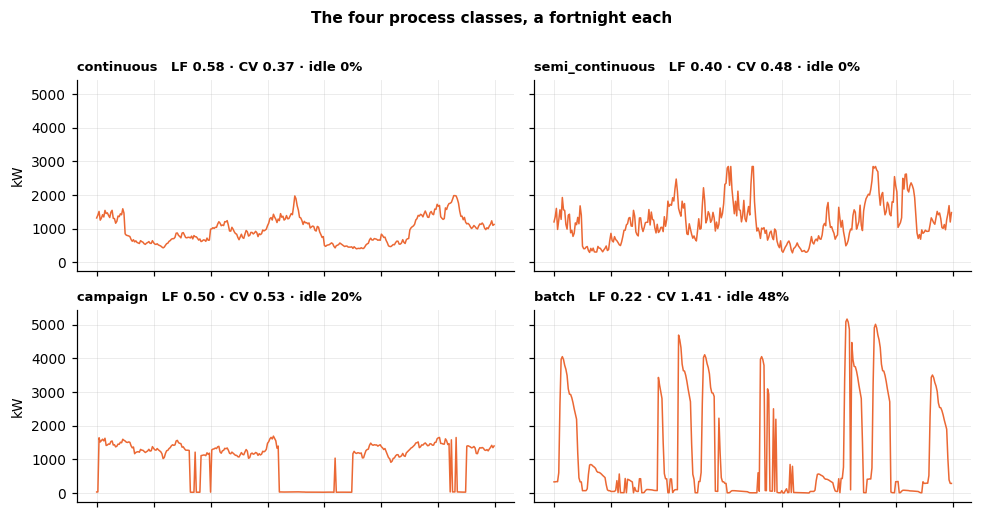

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(9, 4.6), sharey=True)
for ax, name in zip(axes.flat, ["continuous", "semi_continuous", "campaign", "batch"]):
    frame = lc.generate(annual_mwh=10_000, heat_to_cold=None, elec_share=0.0,
                        process_class=name, seed=5)
    s = frame["heat_kw"].iloc[2400:2400 + 336]
    ax.plot(s.index, s.values, color=C["heat"], lw=1.0)
    st = lc.profile_statistics(frame["heat_kw"])
    ax.set_title(f"{name}   LF {st['load_factor']:.2f} · CV {st['cv']:.2f} · idle {st['idle_fraction']:.0%}",
                 loc="left", fontsize=8.5)
    ax.tick_params(labelbottom=False)
axes[0, 0].set_ylabel("kW"); axes[1, 0].set_ylabel("kW")
plt.suptitle("The four process classes, a fortnight each", y=1.01, fontsize=10, fontweight="bold")
save("06_process_classes")
plt.show()

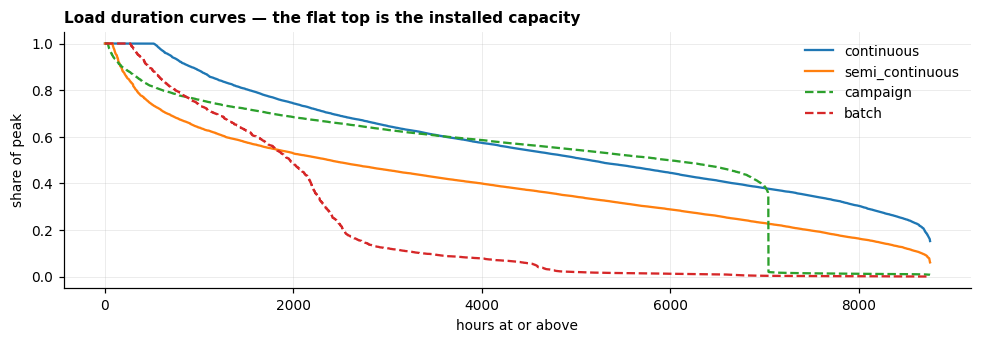

In [11]:
fig, ax = plt.subplots(figsize=(9, 3.2))
for name, style in zip(["continuous", "semi_continuous", "campaign", "batch"],
                       ["-", "-", "--", "--"]):
    frame = lc.generate(annual_mwh=10_000, heat_to_cold=None, elec_share=0.0,
                        process_class=name, seed=5)
    ax.plot(lc.duration_curve(frame["heat_kw"]), ls=style, lw=1.5, label=name)
ax.set_xlabel("hours at or above"); ax.set_ylabel("share of peak")
ax.set_title("Load duration curves — the flat top is the installed capacity", loc="left")
ax.legend()
save("06_duration_curves")
plt.show()

The flat top is the capacity cap doing its work: without it the lognormal tail
runs away and the load factor collapses, even when the coefficient of variation
is correct. The two dashed classes have an on/off mask, which is what puts a
long near-zero tail on the right — spread alone cannot produce that.

---
## 7. The coincidence problem

This is why the package exists.

Designing anything with storage needs to know not just *how much* of each carrier
a site wants, but **whether it wants them at the same hours**. A store exists
precisely to bridge the hours when it does not.

Published multi-carrier industrial data cannot answer that, because of how it is
built. Every carrier is a fixed scalar times one shared temporal profile,
$P_m(t) = \kappa_m\,p(t)$, and under that construction

$$
\operatorname{corr}(P_m, P_n)
= \operatorname{corr}(\kappa_m p,\ \kappa_n p) = 1
$$

identically, for every pair — by algebra, not by measurement. Reconstruct it and
see:

In [12]:
# The published construction: one profile, three fixed scalars.
rng = np.random.default_rng(7)
shared = np.abs(generator.lognormal_from_latent(
    generator.correlated_ar1(8760, 1, 0.9, 0.4, 0.0, rng), 0.4)[0])
published = pd.DataFrame({"heat_kw": 3.0 * shared,
                          "cold_kw": 0.4 * shared,
                          "elec_kw": 1.0 * shared}, index=index)

print("Disaggregated construction, P_m(t) = κ_m · p(t):")
print(f"  corr(heat, cold) = {published['heat_kw'].corr(published['cold_kw']):.6f}")
print(f"  cold/heat ratio  : constant to {np.ptp(published['cold_kw']/published['heat_kw']):.2e} over 8760 h")
print()
gen = lc.generate(annual_mwh=10_000, heat_to_cold=2.0, elec_share=0.2,
                  carrier_correlation=0.60, seed=3)
print("loadcast, same annual quantities:")
print(f"  corr(heat, cold) = {gen['heat_kw'].corr(gen['cold_kw']):.6f}")
print(f"  cold/heat ratio  : varies over a range of {np.ptp(gen['cold_kw']/gen['heat_kw']):.2f}")

Disaggregated construction, P_m(t) = κ_m · p(t):
  corr(heat, cold) = 1.000000
  cold/heat ratio  : constant to 5.55e-17 over 8760 h

loadcast, same annual quantities:
  corr(heat, cold) = 0.595197
  cold/heat ratio  : varies over a range of 2.48


The real dataset behaves exactly like the reconstruction: on the JERICHO-E-usage
regional series the correlation between carriers is 1.000000 to six decimals
across every region and carrier pair, and the cooling-to-heat ratio is constant
to one part in $10^8$ over 8760 hours. The same artefact appears *in space*: the
composition is identical across all 38 NUTS2 regions to four parts in $10^8$,
while the regions' scale varies by a factor of 17.9.

A study of storage that inherits this concludes that a perfectly matched host is
achievable — because in its input data, the carriers never disagree.

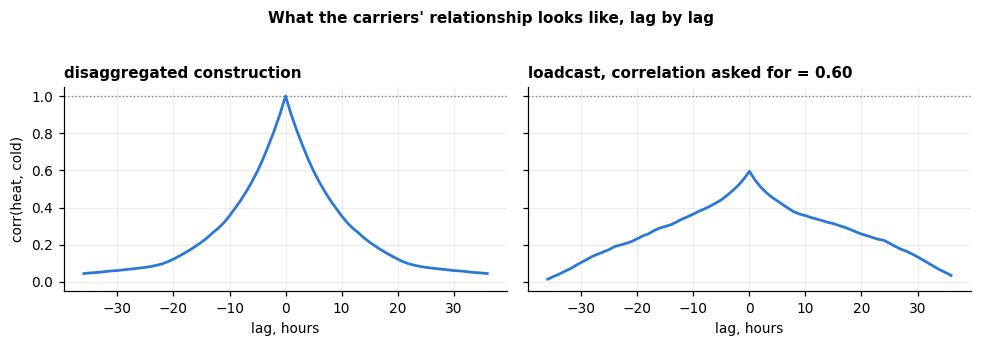

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.0), sharey=True)
for ax, (frame, title) in zip(axes, [
        (published, "disaggregated construction"),
        (gen, "loadcast, correlation asked for = 0.60")]):
    cg = lc.cross_correlogram(frame["heat_kw"], frame["cold_kw"], max_lag=36)
    ax.plot(cg["lag_h"], cg["correlation"], color=C["cold"], lw=1.8)
    ax.set_ylim(-0.05, 1.05)
    ax.axhline(1.0, color="#83807a", ls=":", lw=0.9)
    ax.set_xlabel("lag, hours"); ax.set_title(title, loc="left")
axes[0].set_ylabel("corr(heat, cold)")
plt.suptitle("What the carriers' relationship looks like, lag by lag",
             y=1.03, fontsize=10, fontweight="bold")
save("07_coincidence")
plt.show()

### The knob is not the observable

Carriers share a calendar, so the finished profiles are correlated **even when
their residuals are independent** — everything dips on a Sunday and in July.
Writing $q = \rho_R\,\mathrm{CV}_R^2$, the finished correlation is

$$
\gamma(0) = \frac{\mathrm{CV}_S^2 + q + \mathrm{CV}_S^2\,q}{\mathrm{CV}_{\text{tot}}^2}
$$

Set $q = 0$ and a floor appears:

$$
\boxed{\;\gamma(0)\big|_{\rho=0} = \frac{\mathrm{CV}_S^2}{\mathrm{CV}_{\text{tot}}^2}\;}
$$

**The correlation floor is the share of total variance the shared calendar
contributes.** Read it as a statement about industry rather than as plumbing:
where the floor is high, carriers move together mainly because the factory is
open or shut — not because the processes are physically linked.

In [14]:
rows = []
for name in ["continuous", "semi_continuous", "campaign", "batch"]:
    pc = lc.get_class(name)
    cal = pc.calendar(index)
    cvs = cal.std() / cal.mean()
    rows.append({"class": name, "CV_S": round(cvs, 3),
                 "CV_tot": pc.target_cv, "floor g(0)": round(lc.correlation_floor(name), 3)})
pd.DataFrame(rows).set_index("class")

,CV_S,CV_tot,floor g(0)
class,,,
continuous,0.247,0.409,0.364
semi_continuous,0.315,0.478,0.434
campaign,0.146,0.527,0.077
batch,0.944,1.177,0.644


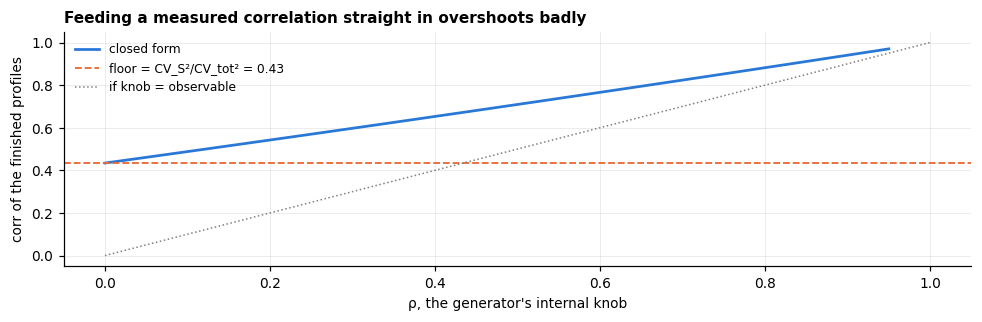

In [15]:
cv_s_demo, cv_r_demo = 0.315, 0.343
knobs = np.linspace(0, 0.95, 40)
delivered = [fitting.correlation_transfer(k, cv_s_demo, cv_r_demo) for k in knobs]

fig, ax = plt.subplots(figsize=(9, 3.0))
ax.plot(knobs, delivered, color=C["cold"], lw=1.8, label="closed form")
ax.axhline(delivered[0], color=C["heat"], ls="--", lw=1.2,
           label=f"floor = CV_S²/CV_tot² = {delivered[0]:.2f}")
ax.plot([0, 1], [0, 1], color="#83807a", ls=":", lw=1.0, label="if knob = observable")
ax.set_xlabel("ρ, the generator's internal knob")
ax.set_ylabel("corr of the finished profiles")
ax.set_title("Feeding a measured correlation straight in overshoots badly", loc="left")
ax.legend(fontsize=8)
save("07_transfer")
plt.show()

---
## 8. The lag, and why it cannot be fitted

Carrier $m$'s stochastic part is shifted by $\tau_m$ hours; the calendar is
shared and **not** shifted, because a factory's opening hours are common to
everything it runs. A circular shift is a permutation, so every statistic of the
shifted carrier is unchanged — the lag is a pure cross-carrier knob.

$$
\gamma(\ell) = \frac{\mathrm{CV}_S^2\,a_S(\ell) + q(\ell-\tau)
+ \mathrm{CV}_S^2\,a_S(\ell)\,q(\ell-\tau)}{\mathrm{CV}_{\text{tot}}^2}
$$

with $a_S(\ell)$ the calendar's own autocorrelation and
$q(u) = \mathrm{CV}_R^2\rho_R(u)$ decaying like $\phi^{|u|}$.

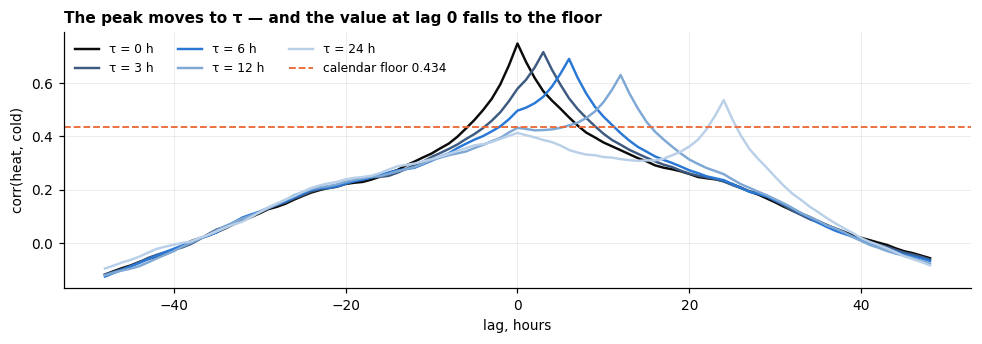

,peak at,peak r,r at lag 0
τ (h),,,
0,0,0.748,0.748
3,3,0.716,0.579
6,6,0.691,0.496
12,12,0.630,0.432
24,24,0.536,0.413


In [16]:
fig, ax = plt.subplots(figsize=(9, 3.2))
floor = lc.correlation_floor("semi_continuous")
rows = []
for tau, shade in zip([0, 3, 6, 12, 24], ["#0b0b0b", "#3d5a80", C["cold"], "#7fa8d4", "#b9d0e8"]):
    frame = lc.generate(annual_mwh=10_000, heat_to_cold=2.0, elec_share=0.2,
                        carrier_correlation=0.75, carrier_lag_h={"cold": tau}, seed=11)
    cg = lc.cross_correlogram(frame["heat_kw"], frame["cold_kw"], max_lag=48)
    ax.plot(cg["lag_h"], cg["correlation"], color=shade, lw=1.6, label=f"τ = {tau} h")
    peak = cg.loc[cg["correlation"].idxmax()]
    rows.append({"τ (h)": tau, "peak at": int(peak["lag_h"]), "peak r": round(peak["correlation"], 3),
                 "r at lag 0": round(float(cg.loc[cg["lag_h"] == 0, "correlation"].iloc[0]), 3)})
ax.axhline(floor, color=C["heat"], ls="--", lw=1.2, label=f"calendar floor {floor:.3f}")
ax.set_xlabel("lag, hours"); ax.set_ylabel("corr(heat, cold)")
ax.set_title("The peak moves to τ — and the value at lag 0 falls to the floor", loc="left")
ax.legend(fontsize=8, ncol=3)
save("08_lag")
plt.show()

pd.DataFrame(rows).set_index("τ (h)")

Read the table, not just the picture. **A lag and a weak coupling are
indistinguishable at lag zero**: as $\tau$ grows, the contemporaneous
correlation decays towards the calendar floor — exactly where a small $\rho$
would also put it. A single reported correlation therefore does not identify a
multi-carrier demand model; only the correlogram separates them.

Two consequences, and the package acts on both:

1. **The lag is exogenous.** No public archive meters process heat and
   refrigeration at one industrial site, so no heat-to-cold lag can be fitted.
   Sweeping it is the honest treatment, not a fallback.
2. **`carrier_correlation` is defined at peak alignment**, so a lag sweep
   changes timing only, rather than quietly changing coupling strength too.

---
## 9. What a store actually responds to

A buffer does not *sample* a mismatch, it **integrates** one. For
$m(t) = h(t)/\bar h - c(t)/\bar c$,

$$
\operatorname{Var}\!\left(\sum_{s=1}^{T} m(s)\right)
= \sum_{|u| < T} (T - |u|)\; C_m(u)
$$

a triangularly weighted sum over the whole correlogram. Correlation is $C_m(0)$
— a single point of it. So two carrier pairs with the *same* correlation can
demand very different amounts of buffering, and the lag is the most direct
handle on the difference.

In [17]:
rows = []
for tau in [0, 3, 6, 12, 24]:
    frame = lc.generate(annual_mwh=10_000, heat_to_cold=2.0, elec_share=0.2,
                        carrier_correlation=0.75, carrier_lag_h={"cold": tau}, seed=11)
    h, c = frame["heat_kw"], frame["cold_kw"]
    rows.append({"τ (h)": tau,
                 "corr at lag 0": round(h.corr(c), 3),
                 "drift, 6 h window": round(lc.integrated_drift(h, c, 6), 2),
                 "drift, 24 h window": round(lc.integrated_drift(h, c, 24), 2),
                 "drift, 72 h window": round(lc.integrated_drift(h, c, 72), 2)})
pd.DataFrame(rows).set_index("τ (h)")

,corr at lag 0,"drift, 6 h window","drift, 24 h window","drift, 72 h window"
τ (h),,,,
0,0.748,1.22,3.30,6.27
3,0.579,1.40,3.46,6.48
6,0.496,1.64,3.68,6.71
12,0.432,1.84,4.22,7.08
24,0.413,1.87,4.97,7.80


---
## 10. Resolution

Resolution is a rendering choice, not a change of site, so three things must
survive it.

**Persistence is rescaled.** $\phi$ is a per-*step* coefficient, but persistence
is a property of time. An AR(1) decays as $\phi^k$ over $k$ steps, so a series
sampled every $h$ hours needs

$$
\phi_{\text{step}} = \phi_{\text{hourly}}^{\,h}
$$

Without this a quarter-hourly profile carries four times the memory in real
time. **Energy is power times elapsed hours**, not step count. And **a lag is
given in hours** at any resolution.

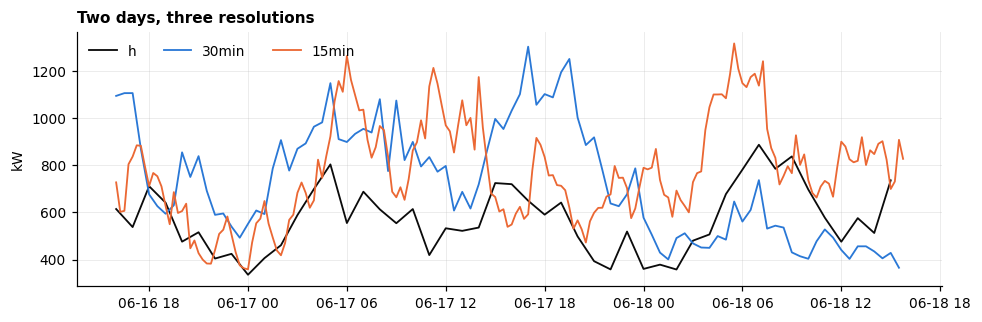

,steps,heat MWh,load factor,lag-1 per step,lag-1 per hour
freq,,,,,
h,8760,5333.3,0.401,0.865,0.865
30min,17520,5333.3,0.401,0.929,0.863
15min,35040,5333.3,0.401,0.964,0.863


In [18]:
rows = []
fig, ax = plt.subplots(figsize=(9, 3.0))
for freq, mult, colour in [("h", 1, "#0b0b0b"), ("30min", 2, C["cold"]), ("15min", 4, C["heat"])]:
    frame = lc.generate(annual_mwh=10_000, heat_to_cold=2.0, elec_share=0.2,
                        carrier_correlation=0.75, carrier_lag_h={"cold": 6},
                        freq=freq, seed=2)
    st = lc.profile_statistics(frame["heat_kw"])
    hours = len(frame) / mult
    rows.append({"freq": freq, "steps": len(frame),
                 "heat MWh": round(frame["heat_kw"].mean() * hours / 1000, 1),
                 "load factor": round(st["load_factor"], 3),
                 "lag-1 per step": round(st["lag1"], 3),
                 "lag-1 per hour": round(st["lag1"] ** mult, 3)})
    day = frame["heat_kw"].iloc[4000 * mult:4000 * mult + 48 * mult]
    ax.plot(day.index, day.values, color=colour, lw=1.2, label=freq)
ax.set_ylabel("kW"); ax.set_title("Two days, three resolutions", loc="left")
ax.legend(ncol=3)
save("10_resolution")
plt.show()

pd.DataFrame(rows).set_index("freq")

Energy, load factor and the *hourly-equivalent* persistence are the same on all
three grids; only the row count changes.

One honest caveat: the process classes were calibrated on **hourly** meters, so
their spread and persistence describe hourly behaviour. Asking for 15-minute
steps renders those hourly statistics on a finer grid — it does not add measured
sub-hourly structure, because none was measured. The calendar likewise resolves
only to hour-of-day.

---
## 11. Waste heat

Waste heat is a **by-product the site rejects**, not energy it buys. So it takes
no share of the annual total: it is sized off the heat demand instead, through
`waste_to_heat`.

It carries its own residual. Deriving it as a fixed multiple of the heat demand
would reintroduce exactly the perfect-coupling artefact of section 7.

demand (heat+cold+elec)  10,000.0 MWh  — as asked
waste heat rejected       5,120.0 MWh  = 0.80 × heat
corr(heat, waste)           0.642    — a knob, not 1.000


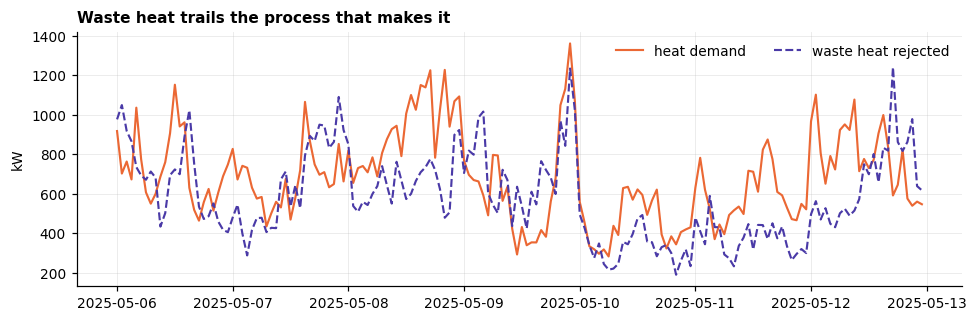

In [19]:
frame = lc.generate(annual_mwh=10_000, heat_to_cold=4.0, elec_share=0.2,
                    carrier_correlation=0.75, waste_to_heat=0.8,
                    carrier_lag_h={"waste": 2}, seed=4)
energy = frame.sum() / 1000
print(f"demand (heat+cold+elec) {energy[['heat_kw','cold_kw','elec_kw']].sum():9,.1f} MWh  — as asked")
print(f"waste heat rejected     {energy['waste_kw']:9,.1f} MWh  = {energy['waste_kw']/energy['heat_kw']:.2f} × heat")
print(f"corr(heat, waste)       {frame['heat_kw'].corr(frame['waste_kw']):9.3f}    — a knob, not 1.000")

span = frame.iloc[3000:3000 + 168]
fig, ax = plt.subplots(figsize=(9, 3.0))
ax.plot(span.index, span["heat_kw"], color=C["heat"], lw=1.4, label="heat demand")
ax.plot(span.index, span["waste_kw"], color=C["waste"], lw=1.4, ls="--", label="waste heat rejected")
ax.set_ylabel("kW"); ax.set_title("Waste heat trails the process that makes it", loc="left")
ax.legend(ncol=2)
save("11_waste")
plt.show()

---
## 12. Fitting your own site

If none of the four classes matches your process, build one from statistics you
measured. The inversion of section 4 does the work.

**Feed it measurements, never generated output.** The generator delivers
persistence slightly off target, and that offset is harmless once but compounds
if you measure a generated profile and feed the result back in.

In [20]:
mine = lc.class_from_observations(
    "my_plant", load_factor=0.45, cv=0.60, lag1=0.90,
    calendar_from="semi_continuous",
)
lc.register_class(mine, overwrite=True)

frame = lc.generate(annual_mwh=5_000, heat_to_cold=3.0, elec_share=0.15,
                    process_class="my_plant", seed=8)
st = lc.profile_statistics(frame["heat_kw"])
print(f"asked for : LF 0.45   CV 0.60   lag-1 0.90")
print(f"got       : LF {st['load_factor']:.2f}   CV {st['cv']:.2f}   lag-1 {st['lag1']:.2f}")

asked for : LF 0.45   CV 0.60   lag-1 0.90
got       : LF 0.45   CV 0.52   lag-1 0.91


Load factor is **imposed** and comes out exact. Spread and persistence are
**aimed at**, and land close but not on target. `bias_report()` shows how close,
and the sign of the offset differs by class: a capacity cap trims the peaks that
would break up a run, while an on/off mask chops runs into pieces.

In [21]:
lc.bias_report(seeds=2)[["load_factor_target", "load_factor_mean",
                         "cv_target", "cv_mean", "cv_bias",
                         "lag1_target", "lag1_mean", "lag1_bias"]]

,load_factor_target,load_factor_mean,cv_target,cv_mean,cv_bias,lag1_target,lag1_mean,lag1_bias
class,,,,,,,,
batch,0.221,0.221,1.177,1.4082,0.2312,0.848,0.7524,-0.0956
campaign,0.503,0.503,0.527,0.5253,-0.0017,0.957,0.7880,-0.1690
continuous,0.576,0.576,0.409,0.3583,-0.0507,0.973,0.9725,-0.0005
semi_continuous,0.401,0.401,0.478,0.4655,-0.0125,0.793,0.8644,0.0714


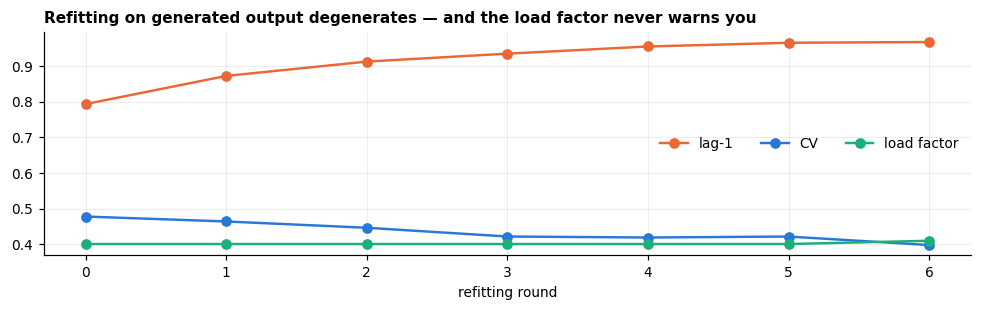

,load factor,CV,lag-1
round,,,
0,0.401,0.478,0.793
1,0.401,0.464,0.872
2,0.401,0.447,0.912
3,0.401,0.422,0.934
4,0.401,0.419,0.954
5,0.401,0.422,0.965
6,0.410,0.398,0.967


In [22]:
# What happens if you *do* close the loop. Never do this.
lf, cv, lag1 = 0.401, 0.478, 0.793
history = [(0, lf, cv, lag1)]
for it in range(1, 7):
    cls = lc.class_from_observations(f"_r{it}", load_factor=lf, cv=cv,
                                     lag1=min(lag1, 0.99),
                                     calendar_from="semi_continuous")
    lc.register_class(cls, overwrite=True)
    st = lc.profile_statistics(
        lc.generate(annual_mwh=10_000, heat_to_cold=2.0, elec_share=0.2,
                    process_class=f"_r{it}", seed=300 + it)["heat_kw"])
    lf, cv, lag1 = st["load_factor"], st["cv"], st["lag1"]
    history.append((it, lf, cv, lag1))

degen = pd.DataFrame(history, columns=["round", "load factor", "CV", "lag-1"]).set_index("round")
fig, ax = plt.subplots(figsize=(9, 2.9))
ax.plot(degen.index, degen["lag-1"], color=C["heat"], marker="o", lw=1.6, label="lag-1")
ax.plot(degen.index, degen["CV"], color=C["cold"], marker="o", lw=1.6, label="CV")
ax.plot(degen.index, degen["load factor"], color=C["elec"], marker="o", lw=1.6, label="load factor")
ax.set_xlabel("refitting round"); ax.set_title(
    "Refitting on generated output degenerates — and the load factor never warns you", loc="left")
ax.legend(ncol=3)
save("12_degeneration")
plt.show()
degen.round(3)

Persistence ratchets towards a fixed point near 0.97 while the spread bleeds
away: the profile grows smoother and stickier every round until it has lost the
high-frequency variability it was supposed to have. This is the standard
degeneration of any model retrained on its own output.

Note the green line. The **load factor never moves**, because it is imposed by
the capacity cap — so an imposed statistic cannot tell you the others are
drifting.

The AR(1) itself is not what breaks: it is stationary by construction, with
$\operatorname{Var}[z_t]=\sigma^2$ at every $t$ and $|\phi|<1$, so it cannot
drift or collapse over any horizon. What degenerates is the estimation loop
wrapped around it. Vary the **seed** for another draw of the same site; never
refit on the output.

---
## 13. Only the carriers you have

A site that buys only electricity, or heat and electricity but no refrigeration,
is perfectly ordinary. The frame always has the same columns so the schema is
stable; the ones you did not ask for are zero.

In [23]:
rows = []
for label, shares in [("heat only", {"heat": 1.0}),
                      ("electricity only", {"elec": 1.0}),
                      ("cold + electricity", {"cold": 0.6, "elec": 0.4}),
                      ("all three", {"heat": 0.5, "cold": 0.25, "elec": 0.25})]:
    spec = lc.DemandSpec.from_shares(shares, annual_mwh=10_000)
    e = lc.generate(spec).sum() / 1000
    rows.append({"site": label, "active": ", ".join(spec.active_carriers),
                 "heat MWh": round(e["heat_kw"]), "cold MWh": round(e["cold_kw"]),
                 "elec MWh": round(e["elec_kw"])})
pd.DataFrame(rows).set_index("site")

,active,heat MWh,cold MWh,elec MWh
site,,,,
heat only,heat,10000,0,0
electricity only,elec,0,0,10000
cold + electricity,"cold, elec",0,6000,4000
all three,"heat, cold, elec",5000,2500,2500


---
## 14. Indicative published values

`loadcast.reference` carries published starting points from three peer-reviewed
sources — each used only for what it resolves, and each shipped **with its
caveat** rather than as a default that quietly becomes an assumption.

In [24]:
lc.reference.sources()[["peer_reviewed", "scope", "used_for"]]

,peer_reviewed,scope,used_for
source,,,
jericho,True,"German industry, 2019, 38 NUTS2 regions","useful energy by carrier, annual totals"
rehfeldt,True,"UK industry, 7 subsectors, two datasets (ECUK ...","heat by temperature band and cooling, shares o..."
tno,True,"EU-28, 2016 production, 4 sectors, ~66 products",process and waste heat quantities with stream ...


In [25]:
print("industry-wide composition (JERICHO, German industry 2019):")
print("  ", lc.reference.industry_composition())
print()
print("subsector heat:cold — the width of published disagreement, not an error bar:")
lc.reference.reference_table()[["heat_to_cold_low", "heat_to_cold_high", "spread"]]

industry-wide composition (JERICHO, German industry 2019):
   {'cold': 0.049, 'elec': 0.213, 'heat': 0.738, 'heat_to_cold': 15.0}

subsector heat:cold — the width of published disagreement, not an error bar:


,heat_to_cold_low,heat_to_cold_high,spread
subsector,,,
Chemicals,6.7,49.0,7.3
"Food, beverages and tobacco",11.5,32.3,2.8
"Iron and steel, non-ferrous metals",NaN,NaN,NaN
Machinery and Transport,49.0,49.0,1.0
Non-metallic minerals,NaN,NaN,NaN
Other industry,NaN,NaN,NaN
Paper,NaN,NaN,NaN


Those ranges are wide because Rehfeldt reports two datasets for the same
subsectors and they disagree by more than the subsectors differ from one
another: for food, heat:cold is 11.5 in one and 32.3 in the other.

And a warning that matters more than the numbers: **branch aggregates cannot
place a site.** Of three metered food plants, none fell inside the published
range for its own branch — the within-branch spread was a factor of 135 against
a branch range of 2.8. Use these to *start* a sweep, never to finish one.

In [26]:
lc.reference.sector_temperatures()[["process_p25_c", "process_median_c",
                                    "process_p75_c", "waste_median_c",
                                    "waste_to_process"]]

,process_p25_c,process_median_c,process_p75_c,waste_median_c,waste_to_process
sector,,,,,
Chemical,71.0,109.6,129.0,52.1,1.0
Food and Beverage,105.5,120.9,180.0,57.0,0.5
Paper,125.0,140.0,157.2,45.0,0.6
Refinery,173.4,275.3,309.0,89.5,2.1


Temperatures are information for a decision the generator does not make.
`loadcast` carries energy by carrier and no temperature at all — whether a
machine can *reach* a process, or usefully lift a waste stream, is answered from
the machine's own limits against numbers like these.

---
## 15. Limits, stated

1. **The cold carrier has no measured shape.** No site in the calibration
   archive meters refrigeration. Its annual quantity is whatever you specify,
   but its hourly shape rests on the same calendar and correlation assumptions
   as the other carriers, and nothing independent confirms it. Every cold result
   carries this.
2. **Two branches, five series.** Food and chemicals. The calibration archive is
   narrow, and that is the package's main limitation — reports that the
   generated profiles disagree with a site you have measured are the most useful
   contribution anyone can make.
3. **Spread and persistence are aimed at, not imposed.** `bias_report()` reports
   the systematic offset; it is recorded rather than tuned away, because a third
   free parameter fitted to close it would be over-fitting.
4. **Sub-hourly output renders hourly statistics on a finer grid.** It does not
   add measured sub-hourly structure.
5. **Temperature is not in the generator.** It carries energy by carrier.
6. **The parameters are yours.** Defaults are indicative values with a stated
   provenance, not predictions about any real site. State results as they hold
   **across a swept space**, not at a single assumed point — a finding that
   survives the whole plausible range of correlations and lags does not depend
   on knowing values nobody can measure.